
* [geogebra](https://www.geogebra.org/calculator/evvh3xmj)

In [ ]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

In [ ]:
x, a, b = sp.symbols('x, a, b')
f = a * sp.sin(b * x)
display(f)

a*sin(b*x)

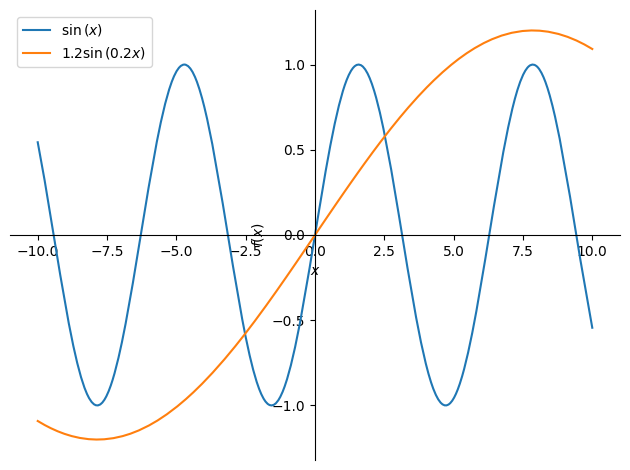

In [ ]:
g1 = f.subs([(b, 1), (a, 1)])
g2 = f.subs([(b, .2), (a, 1.2)])
sp.plot(g1, g2, legend=True)

In [ ]:
f.subs([(b,0), (a,0)])

0

$$
f(x) = \frac{x^2 + ax + 2}{bx^2 + 3x -2 }
$$


In [ ]:
f1 = f.subs([(a,1), (b,2)])
h = sp.lambdify(x, f1)
h(5)

-0.5440211108893698

In [ ]:
A = 4     # ground truth a
B = .6    # ground truth b

gt_f = f.subs([(a, A), (b, B)])    # ground truth f

In [ ]:
def create_cloud():
  global xs, ys
  N = 20
  xs = np.linspace(-10, 10, N)
  ns = np.random.randn(N) * .5
  ys = sp.lambdify(x, gt_f)(xs) + ns
  ys = ys.squeeze()

In [ ]:
def show_function_and_cloud(f):
  xt = np.linspace(-10, 10, 200)
  yt = sp.lambdify(x, f)(xt)

  plt.grid()
  plt.plot(xs, ys, 'rx')
  plt.plot(xt, yt)
  plt.title(f'f(x) = {f}\nCloud: {gt_f} + noise.')
  plt.show()

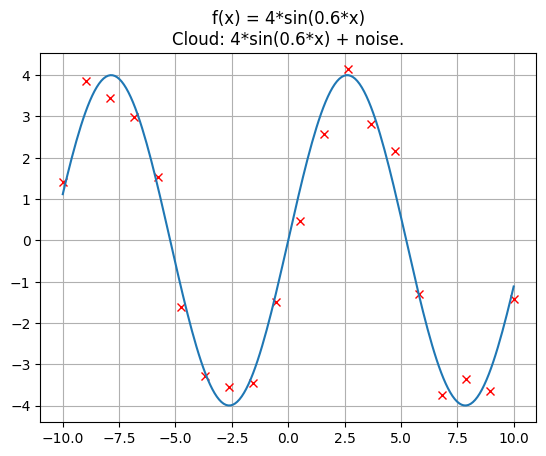

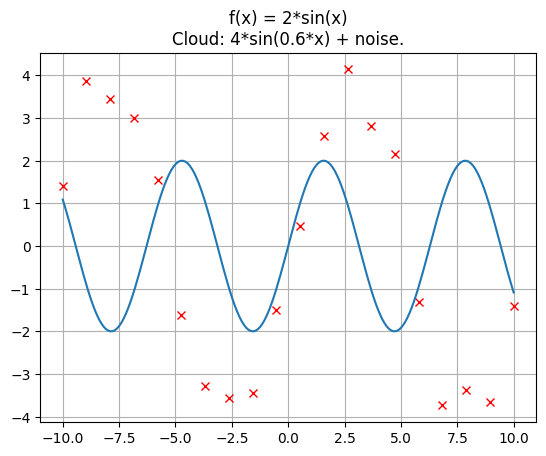

In [ ]:
create_cloud()

show_function_and_cloud(gt_f)
f1 = f.subs([(a, 2), (b, 1)])
show_function_and_cloud(f1)


In [ ]:
def compute_cost_function():
  cost = 0
  N = len(xs)
  for i in range(N):
    xi, yi = xs[i], ys[i]
    cost += (f.subs(x, xi) - yi) ** 2
  cost /= N
  return cost


cost = compute_cost_function()
print('cost(a,b) = ')
display(cost)

cost(a,b) = 


(a*sin(0.526315789473683*b) - 0.458020531321694)**2/20 + 0.112973727203078*(-0.665267447948458*a*sin(0.526315789473685*b) + 1)**2 + 0.329810518604019*(0.389361271036229*a*sin(1.57894736842105*b) - 1)**2 + 0.593614439882393*(-0.29022363267191*a*sin(1.57894736842105*b) + 1)**2 + 0.634169005088358*(-0.280790555540018*a*sin(2.63157894736842*b) + 1)**2 + 0.855860975266833*(0.241703750861857*a*sin(2.63157894736842*b) - 1)**2 + 0.538028818172885*(-0.304847215906138*a*sin(3.68421052631579*b) + 1)**2 + 0.398821105313128*(0.354075547835031*a*sin(3.68421052631579*b) - 1)**2 + 0.231499882170684*(0.464739530612199*a*sin(4.73684210526316*b) - 1)**2 + 0.129059476211415*(-0.622429335540301*a*sin(4.73684210526316*b) + 1)**2 + 0.0849607046849018*(0.767142333462239*a*sin(5.78947368421053*b) + 1)**2 + 0.118376478847095*(-0.649908614242142*a*sin(5.78947368421053*b) - 1)**2 + 0.698289673058523*(0.267588344377974*a*sin(6.84210526315789*b) + 1)**2 + 0.447458687511098*(-0.33427856562157*a*sin(6.84210526315789*

In [ ]:
dJda = cost.diff(a)
dJdb = cost.diff(b)

display(sp.Equality(sp.Derivative('cost(a,b)', a), dJda))
print()
display(sp.Equality(sp.Derivative('cost(a,b)', b), dJdb))

Eq(Derivative(cost(a, b), a), (a*sin(0.526315789473683*b) - 0.458020531321694)*sin(0.526315789473683*b)/10 - 0.150315486363234*(-0.665267447948458*a*sin(0.526315789473685*b) + 1)*sin(0.526315789473685*b) + 0.256830885449558*(0.389361271036229*a*sin(1.57894736842105*b) - 1)*sin(1.57894736842105*b) - 0.344561878298338*(-0.29022363267191*a*sin(1.57894736842105*b) + 1)*sin(1.57894736842105*b) - 0.356137334490041*(-0.280790555540018*a*sin(2.63157894736842*b) + 1)*sin(2.63157894736842*b) + 0.413729615876561*(0.241703750861857*a*sin(2.63157894736842*b) - 1)*sin(2.63157894736842*b) - 0.328033174594548*(-0.304847215906138*a*sin(3.68421052631579*b) + 1)*sin(3.68421052631579*b) + 0.282425602703837*(0.354075547835031*a*sin(3.68421052631579*b) - 1)*sin(3.68421052631579*b) + 0.215174293153566*(0.464739530612199*a*sin(4.73684210526316*b) - 1)*sin(4.73684210526316*b) - 0.1606608080469*(-0.622429335540301*a*sin(4.73684210526316*b) + 1)*sin(4.73684210526316*b) + 0.130353906489143*(0.767142333462239*a*si

Eq(Derivative(cost(a, b), b), 0.0526315789473683*a*(a*sin(0.526315789473683*b) - 0.458020531321694)*cos(0.526315789473683*b) - 0.0791134138753865*a*(-0.665267447948458*a*sin(0.526315789473685*b) + 1)*cos(0.526315789473685*b) + 0.405522450709828*a*(0.389361271036229*a*sin(1.57894736842105*b) - 1)*cos(1.57894736842105*b) - 0.544045070997376*a*(-0.29022363267191*a*sin(1.57894736842105*b) + 1)*cos(1.57894736842105*b) - 0.937203511815898*a*(-0.280790555540018*a*sin(2.63157894736842*b) + 1)*cos(2.63157894736842*b) + 1.08876214704358*a*(0.241703750861857*a*sin(2.63157894736842*b) - 1)*cos(2.63157894736842*b) - 1.20854327482202*a*(-0.304847215906138*a*sin(3.68421052631579*b) + 1)*cos(3.68421052631579*b) + 1.04051537838256*a*(0.354075547835031*a*sin(3.68421052631579*b) - 1)*cos(3.68421052631579*b) + 1.01924665178005*a*(0.464739530612199*a*sin(4.73684210526316*b) - 1)*cos(4.73684210526316*b) - 0.761024880222159*a*(-0.622429335540301*a*sin(4.73684210526316*b) + 1)*cos(4.73684210526316*b) + 0.7546

In [ ]:
def step(f, a0, b0, lr):
  da = dJda.subs([(a, a0), (b, b0)])
  db = dJdb.subs([(a, a0), (b, b0)])
  print(f'{da=:.1} {db=:.1}')
  return a0 - lr * da, b0 - lr * db

In [ ]:
def train(f, epochs=20, lr=1e-3):
  a0, b0 = 3.0, 1.0
  costs = []
  for i in range(epochs):
    c = cost.subs([(a, a0), (b, b0)])
    costs.append(c)
    print(f'step #{i}:    cost={c}  (a0, b0) = ({a0:.2}, {b0:.2})')
    f0 = f.subs([(a,a0), (b,b0)])
    show_function_and_cloud(f0)
    a0, b0 = step(f, a0, b0, lr)

  plt.plot(costs)
  plt.title('cost')
  plt.show()


step #0:    cost=14.3818506017021  (a0, b0) = (3.0, 1.0)


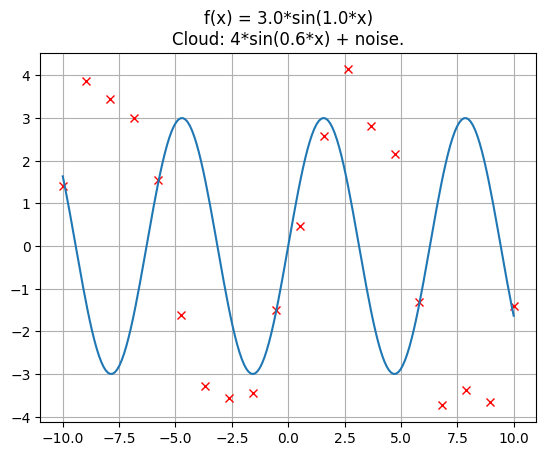

da=4 db=4
step #1:    cost=14.3483252855737  (a0, b0) = (3.0, 1.0)


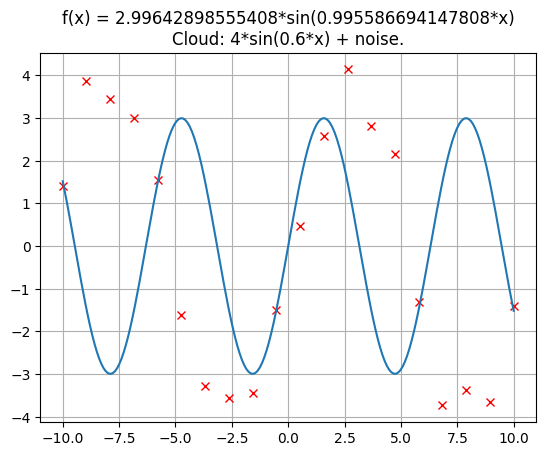

da=4 db=5
step #2:    cost=14.3088861003058  (a0, b0) = (3.0, 0.99)


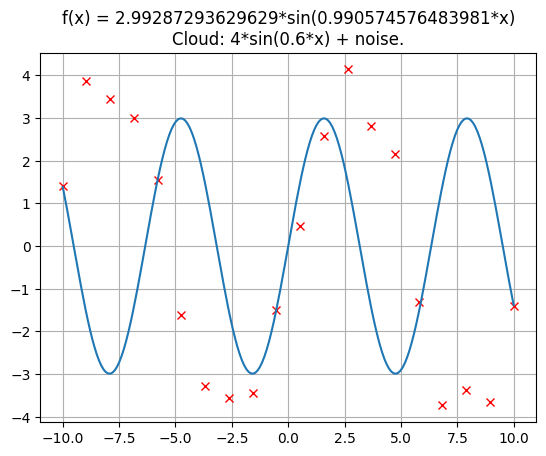

da=4 db=6
step #3:    cost=14.2618029443875  (a0, b0) = (3.0, 0.98)


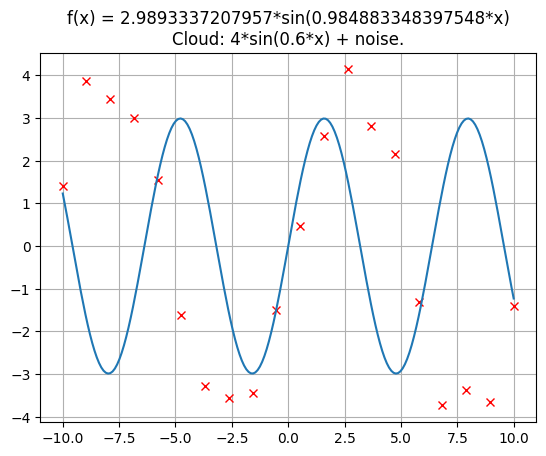

da=4 db=6
step #4:    cost=14.2047812139685  (a0, b0) = (3.0, 0.98)


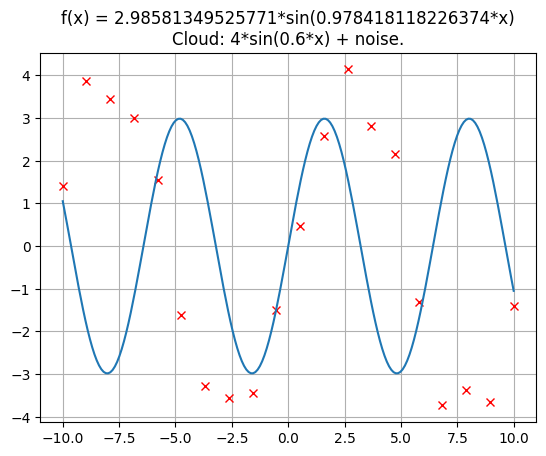

da=3 db=7
step #5:    cost=14.1347011729882  (a0, b0) = (3.0, 0.97)


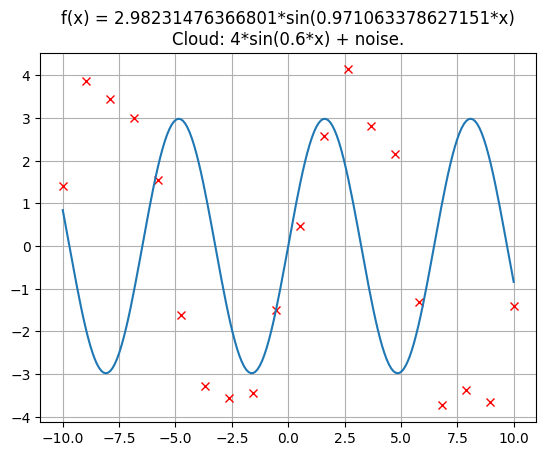

da=3 db=8
step #6:    cost=14.0471765137859  (a0, b0) = (3.0, 0.96)


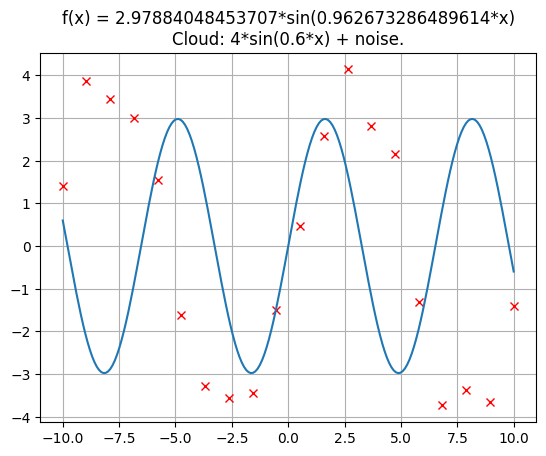

da=3 db=1E+1
step #7:    cost=13.9357744184374  (a0, b0) = (3.0, 0.95)


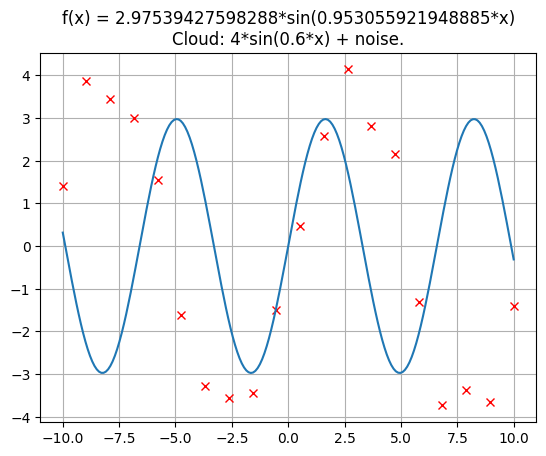

da=3 db=1E+1
step #8:    cost=13.7905805678747  (a0, b0) = (3.0, 0.94)


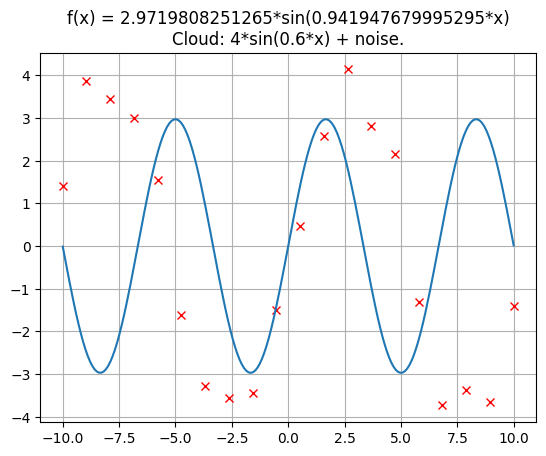

da=3 db=1E+1
step #9:    cost=13.5954480829419  (a0, b0) = (3.0, 0.93)


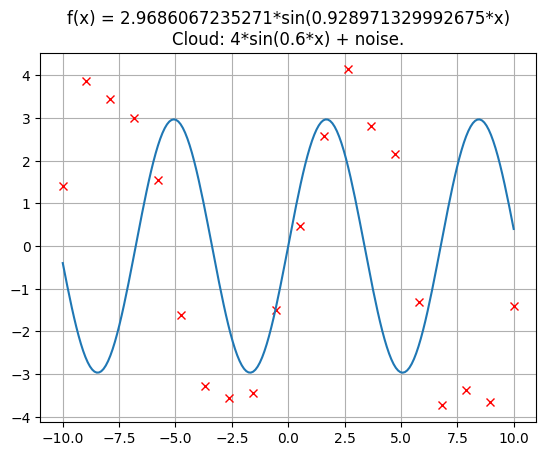

da=3 db=2E+1
step #10:    cost=13.3224997599540  (a0, b0) = (3.0, 0.91)


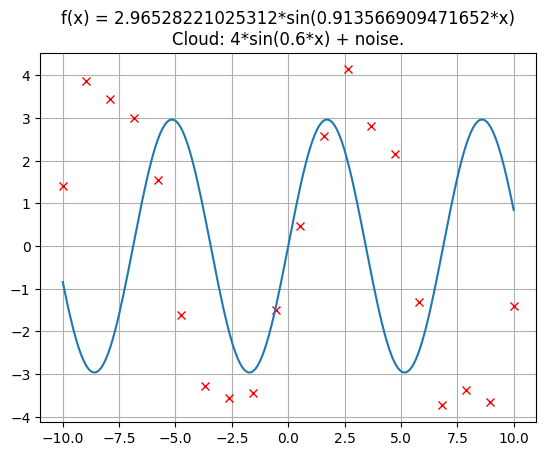

da=3 db=2E+1
step #11:    cost=12.9207453135138  (a0, b0) = (3.0, 0.89)


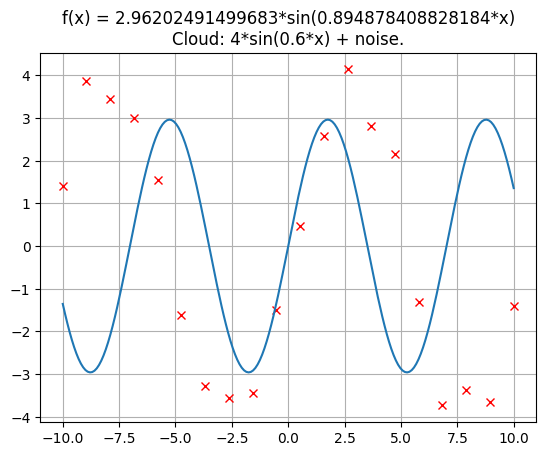

da=3 db=2E+1
step #12:    cost=12.2923437363765  (a0, b0) = (3.0, 0.87)


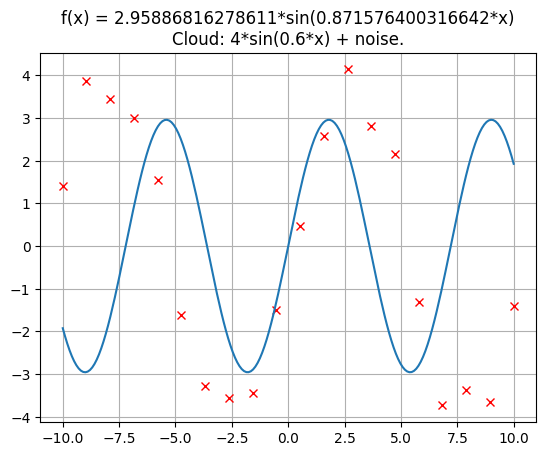

da=3 db=3E+1
step #13:    cost=11.2475607228534  (a0, b0) = (3.0, 0.84)


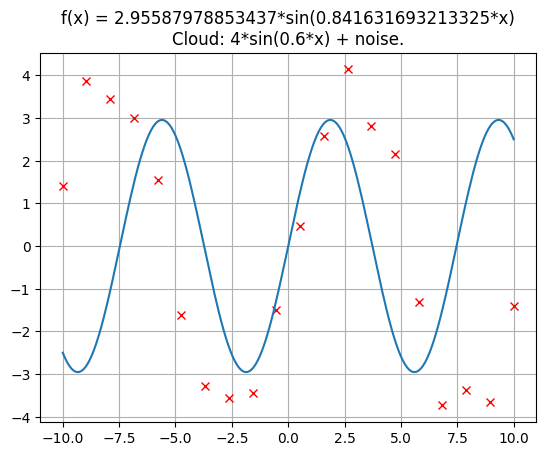

da=3 db=4E+1
step #14:    cost=9.45865288505081  (a0, b0) = (3.0, 0.80)


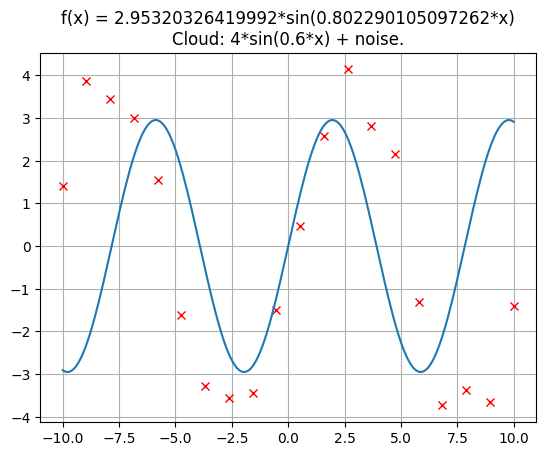

da=2 db=5E+1
step #15:    cost=6.63921774128537  (a0, b0) = (3.0, 0.75)


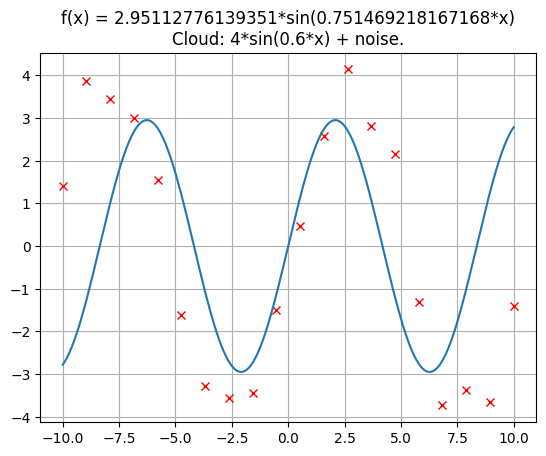

da=1 db=6E+1
step #16:    cost=3.45050519885978  (a0, b0) = (3.0, 0.69)


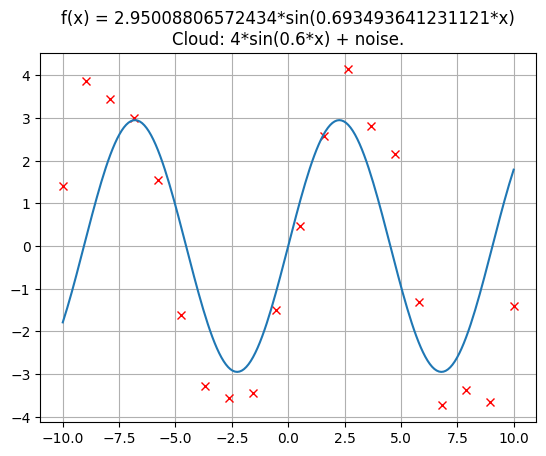

da=-0.2 db=5E+1
step #17:    cost=1.52826185005539  (a0, b0) = (3.0, 0.64)


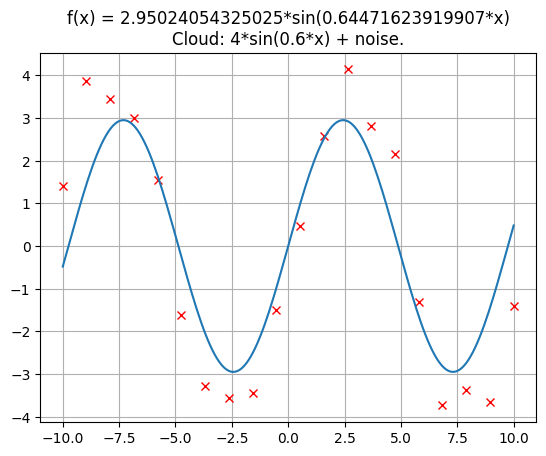

da=-0.8 db=3E+1
step #18:    cost=0.897369298950081  (a0, b0) = (3.0, 0.62)


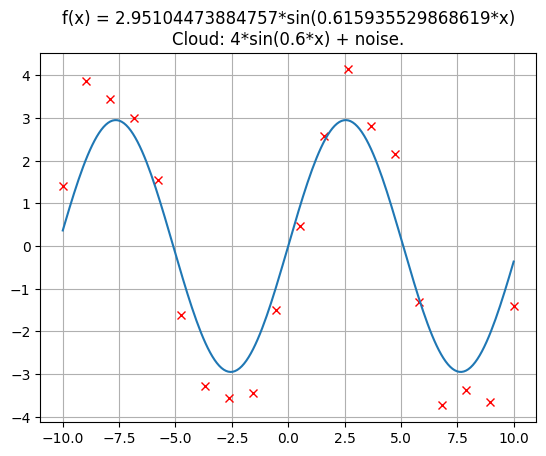

da=-1 db=1E+1
step #19:    cost=0.724566164444429  (a0, b0) = (3.0, 0.60)


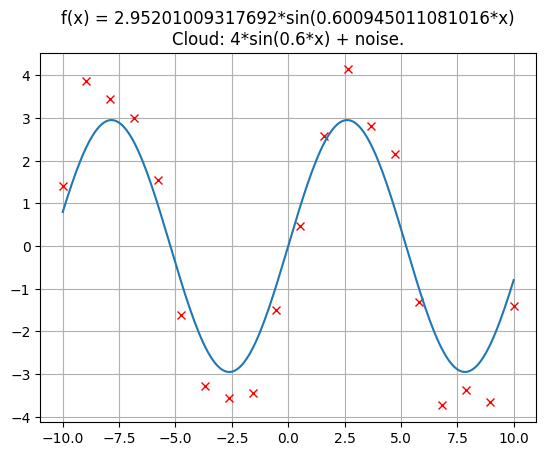

da=-1 db=8
step #20:    cost=0.674170678113087  (a0, b0) = (3.0, 0.59)


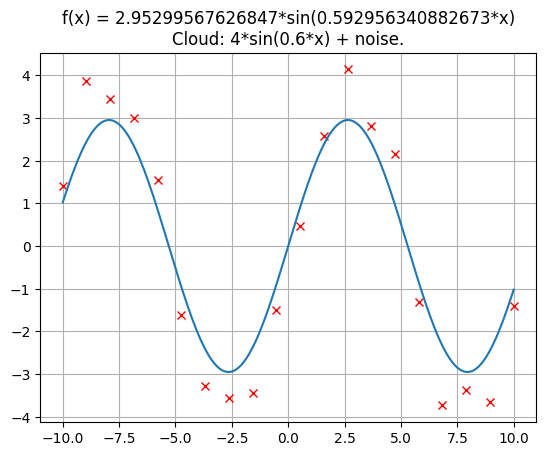

da=-1 db=4
step #21:    cost=0.658048161171358  (a0, b0) = (3.0, 0.59)


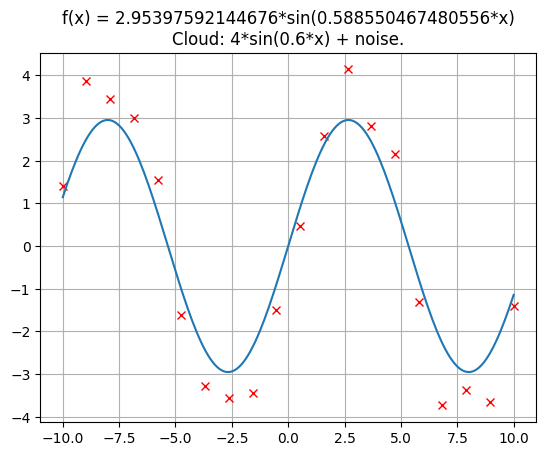

da=-1 db=2
step #22:    cost=0.652255368202887  (a0, b0) = (3.0, 0.59)


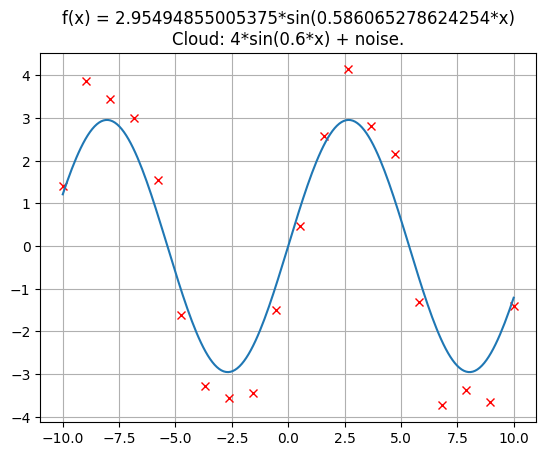

da=-1 db=1
step #23:    cost=0.649735592860992  (a0, b0) = (3.0, 0.58)


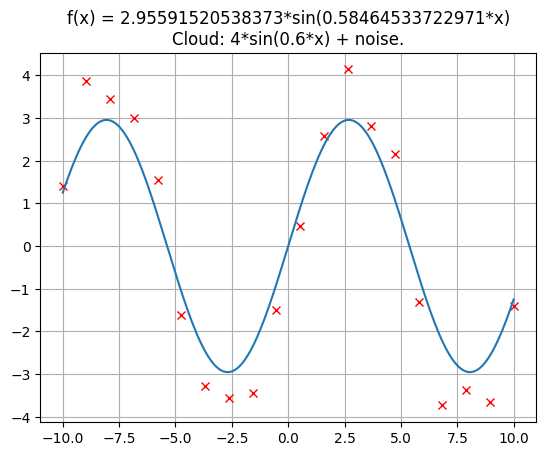

da=-1 db=0.8
step #24:    cost=0.648285193000092  (a0, b0) = (3.0, 0.58)


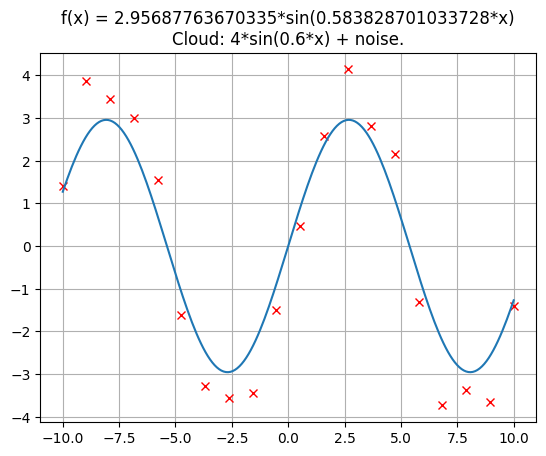

da=-1 db=0.5


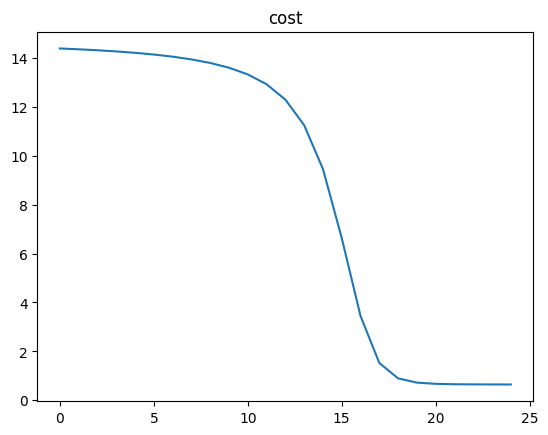

In [ ]:
train(f, 25)